In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.Hamiltonian import Hamiltonian


In [35]:
widthD = 10

X, Y = widthD, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0 * t
mu = np.ones(lattice.X) * muD

U = 0 * np.ones(lattice.X)
V_prime = None

V0 = 6 * t
V = V0 * np.ones(lattice.X)

In [36]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1])

In [37]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=500, temperature=T,verbose=False, mixing=0.6)
F, Fuu, Fdd = H.get_correlations()

Converged after 91 iterations


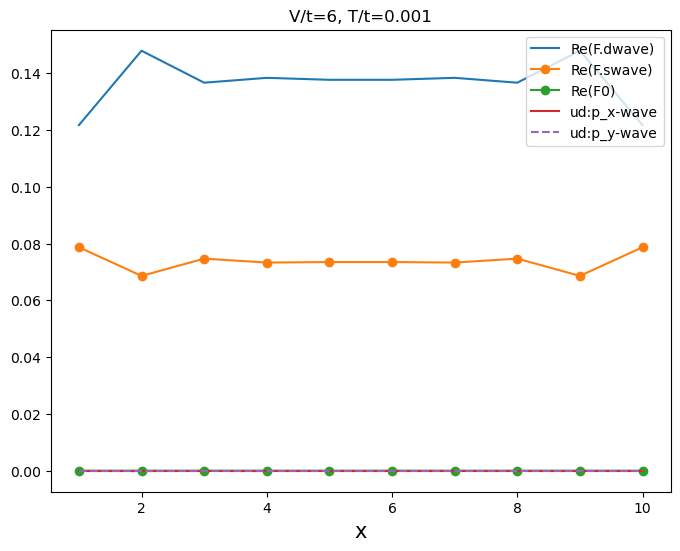

In [38]:
x = np.arange(1, widthD + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.abs(F.swave), '-o', label="Re(F.swave)")
axs.plot(x, np.abs(H.F0), '-o', label="Re(F0)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [34]:
print(F.dwave[X//2])

(0.16489084819350092+0j)


In [63]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.300 + 1e-12, 0.001),
])  # 263 temps total

In [66]:
V_arr = np.array([1,2,3,4,5,
                  5.5,6,6.5,7,
                  7.5,8,8.5,9,9.5])
dwave_arr = np.array([0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
                      0.2, 0.225, 0.25, 0.275,
                      0.3, 0.325, 0.35, 0.375, 0.4 ])

dwave_gaps = V_arr * dwave_arr

print(dwave_gaps)
print(2 * 0.04)
print(0.22*0.3)

[0.07912  0.24388  0.430788 0.626072 0.82445  1.1      1.35     1.625
 1.925    2.25     2.6      2.975    3.375    3.8     ]
0.08
0.066


In [74]:
print(len(temps)*len(V_arr))
print(len(V_arr))
idx = 3681
idx_temp = idx % len(temps)
idx_V = idx // len(temps)
print(idx_temp, idx_V)

3682
14
262 13


In [58]:
widthS = 10

X, Y = widthS, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 1.2 * t
mu = np.ones(lattice.X) * muS

U0 = 3.25
U = U0 * np.ones(lattice.X)
V_prime = None
V = None

In [59]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F0_init=0.2)

In [60]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=500, temperature=T,verbose=False, mixing=0.6)
F, Fuu, Fdd = H.get_correlations()

Converged after 14 iterations


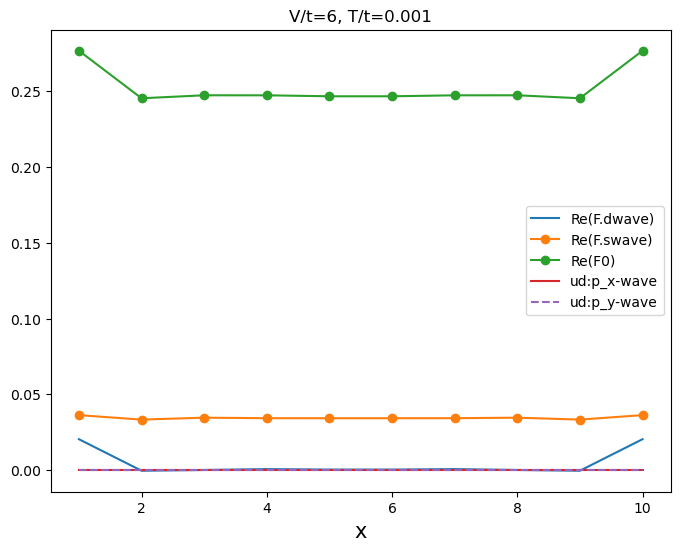

In [61]:
x = np.arange(1, widthD + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.abs(F.swave), '-o', label="Re(F.swave)")
axs.plot(x, np.abs(H.F0), '-o', label="Re(F0)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [62]:
print(H.F0[X//2])
print(U0 * H.F0[X//2])

(0.2467187052653718+0j)
(0.8018357921124584+0j)
